# Data Quality Filtering

## This notebook MUST be run first before any other notebook.

## Output: `data/filtered/markets_filtered.csv` — the only dataset used downstream.

In [3]:
import sys
from pathlib import Path

_root = Path.cwd().resolve()
if not (_root / "src").is_dir():
    _root = _root.parent
sys.path.insert(0, str(_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from src.quality import (
    load_raw,
    apply_quality_filters,
    save_quality_report,
    parse_and_enrich,
    resolved_market_mask,
    print_filter_table,
)
from src.config import (
    DATA_RAW_DIR,
    QUALITY_REPORT_DIR,
    FIGURES_DIR,
    MIN_VOLUME_USD,
    MIN_LIFETIME_DAYS,
    STUCK_PROB_LOW,
    STUCK_PROB_HIGH,
    MIN_LIQUIDITY_USD,
    MIN_CATEGORY_SIZE,
)

config = {
    "MIN_VOLUME_USD": MIN_VOLUME_USD,
    "MIN_LIFETIME_DAYS": MIN_LIFETIME_DAYS,
    "STUCK_PROB_LOW": STUCK_PROB_LOW,
    "STUCK_PROB_HIGH": STUCK_PROB_HIGH,
    "MIN_LIQUIDITY_USD": MIN_LIQUIDITY_USD,
    "MIN_CATEGORY_SIZE": MIN_CATEGORY_SIZE,
}

sns.set_theme(style="whitegrid")
Path(FIGURES_DIR).mkdir(parents=True, exist_ok=True)

In [4]:
df_raw = load_raw(DATA_RAW_DIR)
print(f"\nRaw dataset: {len(df_raw):,} rows, {df_raw.shape[1]} columns")

Loaded: C:\Yatharth\University\MachineLEARNING\hbrm\data\raw\polymarket_markets.csv
Shape: 100,795 rows × 138 columns

Column names and dtypes:
  'acceptingOrders': object
  'acceptingOrdersTimestamp': str
  'active': bool
  'approved': bool
  'archived': bool
  'automaticallyActive': object
  'automaticallyResolved': object
  'bestAsk': float64
  'bestBid': float64
  'category': str
  'categoryMailchimpTag': float64
  'clearBookOnStart': bool
  'clobRewards': str
  'clobTokenIds': str
  'closed': bool
  'closedTime': str
  'commentsEnabled': object
  'competitive': float64
  'conditionId': str
  'createdAt': str
  'createdBy': float64
  'creator': float64
  'customLiveness': float64
  'cyom': bool
  'denominationToken': float64
  'deploying': bool
  'deployingTimestamp': str
  'description': str
  'disqusThread': str
  'enableOrderBook': object
  'endDate': str
  'endDateIso': str
  'eventStartTime': str
  'event_id': int64
  'event_slug': str
  'event_title': str
  'featured': object

In [5]:
df_enriched = parse_and_enrich(df_raw)

resolved_pct = 100.0 * resolved_market_mask(df_raw).mean()
parseable_pct = 100.0 * df_enriched["outcome_binary"].isin([0.0, 1.0]).mean()

vol = df_enriched["volume"]
vol_valid = vol.dropna()
vol_summary = {}
if len(vol_valid) > 0:
    vol_summary = {
        "min": vol_valid.min(),
        "p05": vol_valid.quantile(0.05),
        "median": vol_valid.median(),
        "p95": vol_valid.quantile(0.95),
        "max": vol_valid.max(),
    }

mp = df_enriched["market_prob"]
stuck_mask = (mp < config["STUCK_PROB_LOW"]) | (mp > config["STUCK_PROB_HIGH"])
stuck_pct = 100.0 * (stuck_mask & mp.notna()).mean() if mp.notna().any() else float("nan")

key_cols = [
    "volume",
    "lastTradePrice",
    "outcomePrices",
    "outcomes",
    "category",
    "closed",
    "createdAt",
    "endDate",
    "bestBid",
    "bestAsk",
]
present_keys = [c for c in key_cols if c in df_raw.columns]
missing_pct = {c: 100.0 * df_raw[c].isna().mean() for c in present_keys}

cat_series = df_raw["category"] if "category" in df_raw.columns else pd.Series(dtype=object)
cat_counts = cat_series.fillna("(missing)").astype(str).str.strip()
cat_counts = cat_counts.replace({"": "(missing)", "nan": "(missing)"})
cat_dist = cat_counts.value_counts()

print("=" * 64)
print("RAW DATA HEALTH REPORT (before filtering)")
print("=" * 64)
print(f"\nResolved rows (closed/resolved flag):     {resolved_pct:6.2f}%")
print(f"Parseable binary outcomes (0/1):         {parseable_pct:6.2f}%")
print("\nVolume (USD) — among non-null values:")
if vol_summary:
    for k, v in vol_summary.items():
        print(f"  {k:>6}: {v:,.2f}")
else:
    print("  (no numeric volume)")
print(f"\nRows with market_prob stuck (< {config['STUCK_PROB_LOW']} or > {config['STUCK_PROB_HIGH']}): {stuck_pct:6.2f}%")
print("\n% missing (NaN) in key columns:")
for c, p in sorted(missing_pct.items(), key=lambda x: -x[1]):
    print(f"  {c:20s}  {p:6.2f}%")
print("\nCategory distribution (raw, top 25):")
print(cat_dist.head(25).to_string())
print("\nTune thresholds in src/config.py using the above, then re-run.")

RAW DATA HEALTH REPORT (before filtering)

Resolved rows (closed/resolved flag):      75.73%
Parseable binary outcomes (0/1):          26.58%

Volume (USD) — among non-null values:
     min: 0.00
     p05: 0.00
  median: 3,832.24
     p95: 185,502.79
     max: 94,686,088.64

Rows with market_prob stuck (< 0.02 or > 0.98):  50.77%

% missing (NaN) in key columns:
  category               95.71%
  bestBid                29.19%
  lastTradePrice         10.54%
  outcomePrices           7.78%
  volume                  6.41%
  endDate                 2.04%
  outcomes                0.00%
  closed                  0.00%
  createdAt               0.00%
  bestAsk                 0.00%

Category distribution (raw, top 25):
category
(missing)             96467
Sports                 2540
Crypto                  374
US-current-affairs      339
Pop-Culture             218
Coronavirus             153
Business                137
NBA Playoffs            126
NFTs                    110
Chess           

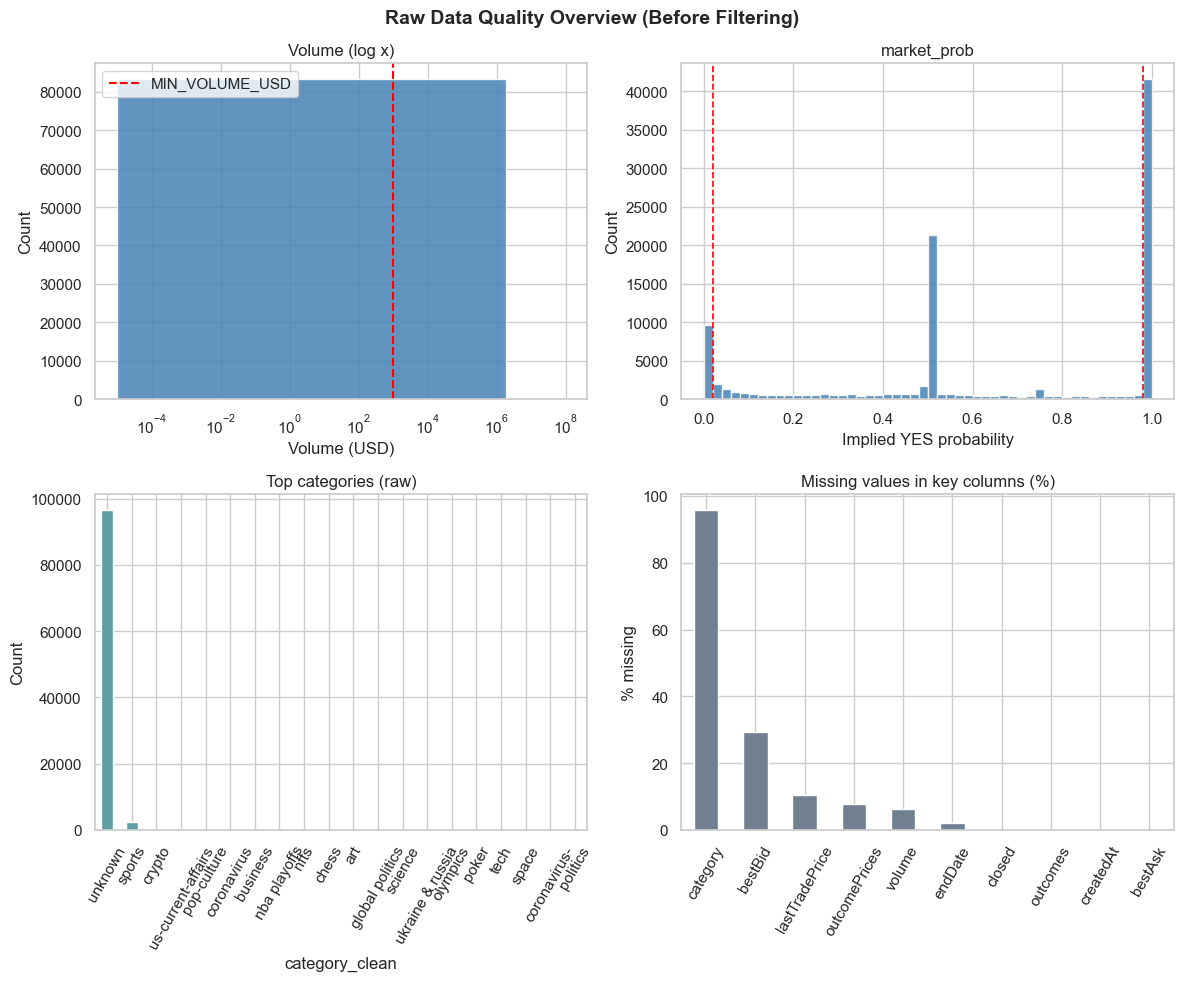

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\00_raw_data_health.png


In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Raw Data Quality Overview (Before Filtering)", fontsize=14, fontweight="bold")

vol_plot = df_enriched["volume"].replace(0, np.nan).dropna()
ax = axes[0, 0]
if len(vol_plot) > 0:
    ax.hist(vol_plot, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.set_xscale("log")
    ax.axvline(config["MIN_VOLUME_USD"], color="red", linestyle="--", linewidth=1.5, label="MIN_VOLUME_USD")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No volume", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Volume (log x)")
ax.set_xlabel("Volume (USD)")
ax.set_ylabel("Count")

ax = axes[0, 1]
mp_plot = df_enriched["market_prob"].dropna()
if len(mp_plot) > 0:
    ax.hist(mp_plot, bins=50, color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(config["STUCK_PROB_LOW"], color="red", linestyle="--", linewidth=1.2)
    ax.axvline(config["STUCK_PROB_HIGH"], color="red", linestyle="--", linewidth=1.2)
else:
    ax.text(0.5, 0.5, "No market_prob", ha="center", va="center", transform=ax.transAxes)
ax.set_title("market_prob")
ax.set_xlabel("Implied YES probability")
ax.set_ylabel("Count")

ax = axes[1, 0]
top_cats = df_enriched["category_clean"].value_counts().head(25)
if len(top_cats) > 0:
    top_cats.plot(kind="bar", ax=ax, color="cadetblue", edgecolor="white")
    ax.tick_params(axis="x", rotation=60)
ax.set_title("Top categories (raw)")
ax.set_ylabel("Count")

ax = axes[1, 1]
if present_keys:
    miss_series = pd.Series(missing_pct).sort_values(ascending=False)
    miss_series.plot(kind="bar", ax=ax, color="slategray", edgecolor="white")
    ax.tick_params(axis="x", rotation=60)
    ax.set_ylabel("% missing")
else:
    ax.text(0.5, 0.5, "No key columns", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Missing values in key columns (%)")

plt.tight_layout()
out_png = Path(FIGURES_DIR) / "00_raw_data_health.png"
plt.savefig(out_png, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png}")

In [7]:
df_filtered, filter_log = apply_quality_filters(df_raw, config)


+-------------------------------------------+----------+----------+
| Filter                                    |  Count   | Removed  |
|-------------------------------------------+----------+----------|
| Raw dataset                               | 100,795  |    -     |
| Resolved markets only                     |  76,331  |  24,464  |
| Binary outcome only                       |  23,924  |  52,407  |
| Volume >= $1,000 USD                      |  19,683  |  4,241   |
| Stuck prices removed (< 0.02 or > 0.98)   |  4,655   |  15,028  |
| Market lifetime >= 7 days                 |  2,408   |  2,247   |
| Liquidity filter                          |  2,408   |    -     |
| Category size >= 20                       |  2,385   |    23    |
| FINAL CLEAN DATASET                       |  2,385   |  98,410  |
+-------------------------------------------+----------+----------+

Retention rate: 2.4% of raw markets kept

Categories retained (count):
  'unknown': 1,249
  'crypto': 221
  'us-cu

In [8]:
save_quality_report(filter_log, df_filtered, QUALITY_REPORT_DIR)
n_raw = len(df_raw)
n_f = len(df_filtered)
print(f"\nOK — Clean dataset saved: {n_f:,} markets")
print(f"OK — Retention rate: {100 * n_f / n_raw:.1f}%")

Wrote: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\quality_report\filter_log.csv
Wrote: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\quality_report\category_counts.csv
Wrote: C:\Yatharth\University\MachineLEARNING\hbrm\data\filtered\markets_filtered.csv

OK — Clean dataset saved: 2,385 markets
OK — Retention rate: 2.4%


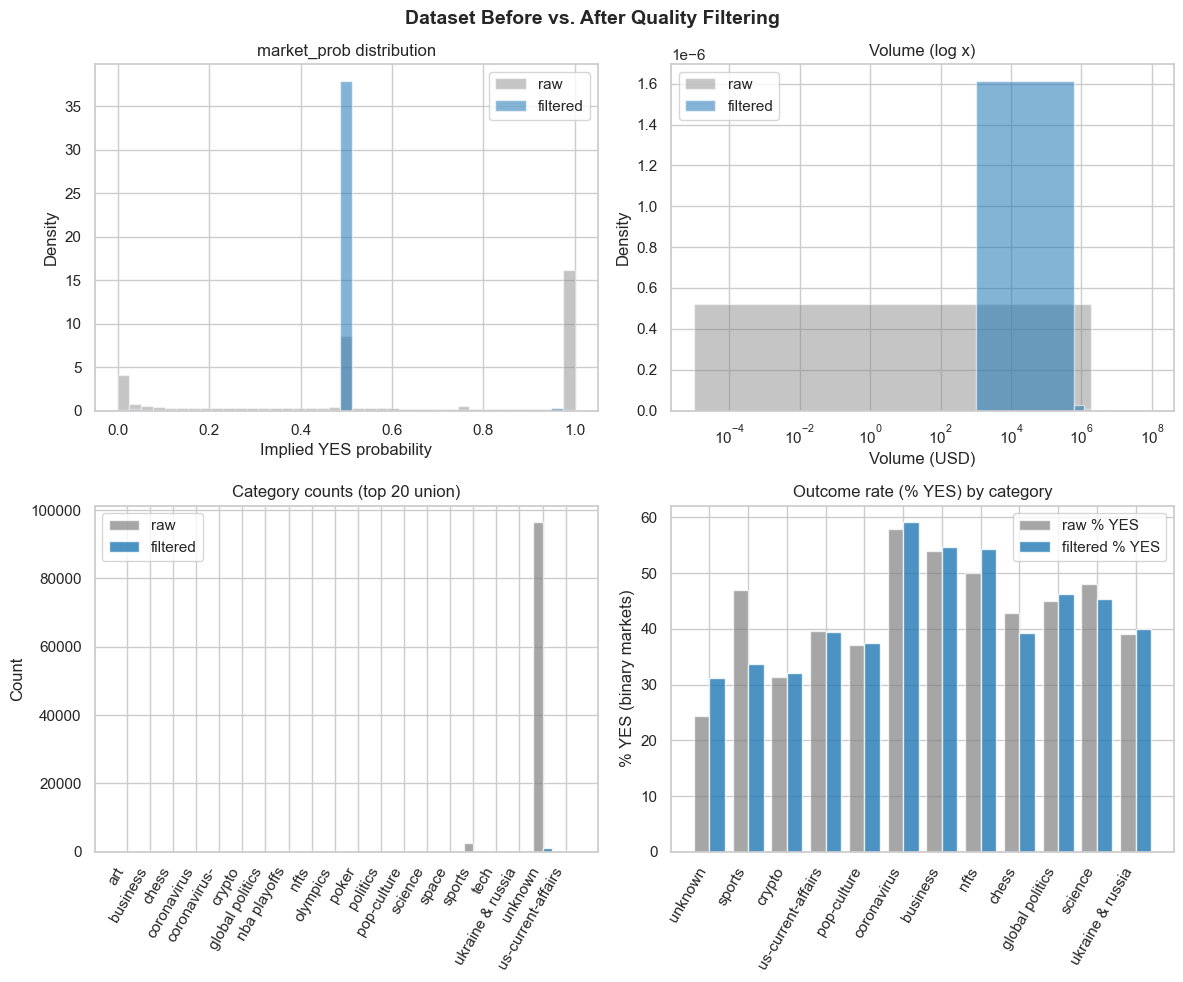

Saved: C:\Yatharth\University\MachineLEARNING\hbrm\outputs\figures\00_before_after_filtering.png


In [9]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))
fig.suptitle("Dataset Before vs. After Quality Filtering", fontsize=14, fontweight="bold")

ax = axes[0, 0]
r_mp = df_enriched["market_prob"].dropna()
f_mp = df_filtered["market_prob"].dropna()
if len(r_mp) > 0 or len(f_mp) > 0:
    bins = np.linspace(0, 1, 40)
    ax.hist(r_mp, bins=bins, color="gray", alpha=0.45, label="raw", density=True)
    ax.hist(f_mp, bins=bins, color="tab:blue", alpha=0.55, label="filtered", density=True)
    ax.legend()
ax.set_title("market_prob distribution")
ax.set_xlabel("Implied YES probability")
ax.set_ylabel("Density")

ax = axes[0, 1]
rv = df_enriched["volume"].replace(0, np.nan).dropna()
fv = df_filtered["volume"].replace(0, np.nan).dropna()
if len(rv) > 0 or len(fv) > 0:
    ax.hist(rv, bins=50, color="gray", alpha=0.45, label="raw", density=True)
    ax.hist(fv, bins=50, color="tab:blue", alpha=0.55, label="filtered", density=True)
    ax.set_xscale("log")
    ax.legend()
ax.set_title("Volume (log x)")
ax.set_xlabel("Volume (USD)")
ax.set_ylabel("Density")

ax = axes[1, 0]
raw_vc = df_enriched["category_clean"].value_counts().head(20)
fil_vc = df_filtered["category_clean"].value_counts().head(20)
all_idx = raw_vc.index.union(fil_vc.index)
raw_aligned = raw_vc.reindex(all_idx, fill_value=0)
fil_aligned = fil_vc.reindex(all_idx, fill_value=0)
x = np.arange(len(all_idx))
w = 0.4
if len(all_idx) > 0:
    ax.bar(x - w / 2, raw_aligned.values, width=w, label="raw", color="gray", alpha=0.7)
    ax.bar(x + w / 2, fil_aligned.values, width=w, label="filtered", color="tab:blue", alpha=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels(list(all_idx), rotation=60, ha="right")
    ax.legend()
ax.set_title("Category counts (top 20 union)")
ax.set_ylabel("Count")

ax = axes[1, 1]
raw_rate = df_enriched.groupby("category_clean")["outcome_binary"].mean() * 100.0
fil_rate = df_filtered.groupby("category_clean")["outcome_binary"].mean() * 100.0
common = raw_rate.index.intersection(fil_rate.index)
common = common[raw_rate.reindex(common).notna() & fil_rate.reindex(common).notna()]
if len(common) > 0:
    top_common = common.tolist()
    top_common = sorted(top_common, key=lambda c: -df_enriched["category_clean"].eq(c).sum())[:20]
    xc = np.arange(len(top_common))
    ax.bar(
        xc - w / 2,
        raw_rate.reindex(top_common).values,
        width=w,
        label="raw % YES",
        color="gray",
        alpha=0.7,
    )
    ax.bar(
        xc + w / 2,
        fil_rate.reindex(top_common).values,
        width=w,
        label="filtered % YES",
        color="tab:blue",
        alpha=0.8,
    )
    ax.set_xticks(xc)
    ax.set_xticklabels(top_common, rotation=60, ha="right")
    ax.legend()
else:
    ax.text(0.5, 0.5, "No overlapping categories", ha="center", va="center", transform=ax.transAxes)
ax.set_title("Outcome rate (% YES) by category")
ax.set_ylabel("% YES (binary markets)")

plt.tight_layout()
out_png2 = Path(FIGURES_DIR) / "00_before_after_filtering.png"
plt.savefig(out_png2, dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {out_png2}")

In [10]:
print("=" * 64)
print("FILTERING SUMMARY (final)")
print("=" * 64)
print_filter_table(filter_log)

print("\nProceed to notebook 01_eda.ipynb using data/filtered/markets_filtered.csv")

kept = sorted((filter_log.get("categories_retained") or {}).items(), key=lambda x: -x[1])
dropped = sorted((filter_log.get("categories_removed") or {}).items(), key=lambda x: -x[1])
print("\nCategories KEPT:")
if not kept:
    print("  (none — check thresholds or raw data)")
for name, cnt in kept:
    print(f"  {name!r}: {cnt:,}")
print("\nCategories DROPPED (too few markets after filters):")
if not dropped:
    print("  (none)")
for name, cnt in dropped:
    print(f"  {name!r}: {cnt:,}")

FILTERING SUMMARY (final)

+-------------------------------------------+----------+----------+
| Filter                                    |  Count   | Removed  |
|-------------------------------------------+----------+----------|
| Raw dataset                               | 100,795  |    -     |
| Resolved markets only                     |  76,331  |  24,464  |
| Binary outcome only                       |  23,924  |  52,407  |
| Volume >= $1,000 USD                      |  19,683  |  4,241   |
| Stuck prices removed (< 0.02 or > 0.98)   |  4,655   |  15,028  |
| Market lifetime >= 7 days                 |  2,408   |  2,247   |
| Liquidity filter                          |  2,408   |    -     |
| Category size >= 20                       |  2,385   |    23    |
| FINAL CLEAN DATASET                       |  2,385   |  98,410  |
+-------------------------------------------+----------+----------+

Retention rate: 2.4% of raw markets kept

Categories retained (count):
  'unknown': 1,24